Dataset Exploration — MC-STGAT-IDS

Section 0 — Setup

Imports, paths, shared helpers. All figures go to `figures/`

In [ ]:
import os, json, pickle, glob
from collections import Counter, defaultdict
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import networkx as nx
from scipy.sparse import coo_matrix
from scipy.sparse.csgraph import connected_components
from torch_geometric.utils import to_networkx

sns.set_theme(context='paper', style='whitegrid', palette='deep')
plt.rcParams.update({'figure.dpi': 120, 'savefig.dpi': 300,
                     'font.size': 10, 'axes.titlesize': 11})

FIGS   = 'figures'
TABLES = 'tables'
os.makedirs(FIGS, exist_ok=True)
os.makedirs(TABLES, exist_ok=True)

def save_fig(fig, name):
    """Save a single figure to figures/<name>.png AND display it inline."""
    path = os.path.join(FIGS, f'{name}.png')
    fig.savefig(path, bbox_inches='tight', dpi=300)
    print(f'  saved {path}')
    plt.show()          # renders inline in the notebook
    plt.close(fig)

DATASETS = {
    'Gotham-2025':      'Gotham_processed_features_10s/graphs',
    'NF-ToN-IoT-v3':    'NFToNIoT_v3_10s/graphs',
    'NF-BoT-IoT-v3':    'NFBoTIoT_v3_10s/graphs',
    'NF-UNSW-NB15-v3':  'NFUNSWNB15_v3_10s/graphs',
}
THRESHOLDS = {
    'Gotham-2025':      0.08,
    'NF-ToN-IoT-v3':    0.15,
    'NF-BoT-IoT-v3':    0.10,
    'NF-UNSW-NB15-v3':  0.08,
}

def slug(name):
    """Filesystem-safe slug for a dataset name."""
    return name.replace(' ', '_').replace('/', '_')

def load_split(root, split):
    p = os.path.join(root, f'{split}_graphs.pkl')
    if not os.path.isfile(p):
        return None
    with open(p, 'rb') as f:
        return pickle.load(f)

def load_norm(root):
    with open(os.path.join(root, 'norm_stats.json')) as f:
        return json.load(f)

def graph_label(g, thr=0.10):
    names = g.edge_attack_names
    if not names:
        return 'Benign'
    c = Counter(names)
    atk = {k: v for k, v in c.items()
           if k not in ('Benign', 'Unknown', 'unknown', 'UNKNOWN')}
    if not atk:
        return 'Benign'
    if sum(atk.values()) / max(sum(c.values()), 1) < thr:
        return 'Benign'
    return max(atk, key=atk.get)

def graph_stats(g):
    n = int(g.x.shape[0])
    m = int(g.edge_index.shape[1])
    if n == 0 or m == 0:
        return n, m, 0.0, 0
    ei = g.edge_index.numpy()
    A = coo_matrix((np.ones(m, dtype=np.int8), (ei[0], ei[1])), shape=(n, n))
    n_comp, _ = connected_components(A, directed=False)
    return n, m, m / max(n, 1), int(n_comp)

def all_graphs(root):
    gs = []
    for s in ('train', 'val', 'test'):
        x = load_split(root, s)
        if x:
            gs += x
    return gs

print('datasets on disk:', [k for k, v in DATASETS.items() if os.path.isdir(v)])

datasets on disk: ['Gotham-2025', 'NF-ToN-IoT-v3', 'NF-BoT-IoT-v3', 'NF-UNSW-NB15-v3']


## Section 1 — Dataset inventory (Table 1)

**Thesis slot:** Table 1, Chapter 4 (Dataset Characterisation).

No figure here — just the summary CSV and an inline preview of the table.

In [ ]:
rows = []
for name, root in DATASETS.items():
    if not os.path.isdir(root):
        continue
    norm = load_norm(root)
    splits = [s for s in (load_split(root, 'train'),
                          load_split(root, 'val'),
                          load_split(root, 'test')) if s]
    total = sum(len(s) for s in splits)
    edges = sum(int(g.edge_index.shape[1]) for s in splits for g in s)
    nodes = sum(int(g.x.shape[0]) for s in splits for g in s)
    rows.append({
        'Dataset': name,
        'Window (s)': norm['window_sec'],
        'Graphs': total,
        'Node-rows': nodes,
        'Edge-rows': edges,
        'Node feats': len(norm['node_cols']),
        'Edge feats': len(norm['edge_cols']),
        'Avg nodes/graph': round(nodes / max(total, 1), 1),
        'Avg edges/graph': round(edges / max(total, 1), 1),
    })

inv = pd.DataFrame(rows)
inv

,Dataset,Window (s),Graphs,Node-rows,Edge-rows,Node feats,Edge feats,Avg nodes/graph,Avg edges/graph
0,Gotham-2025,10,3960,127229,765750,7,10,32.1,193.4
1,NF-ToN-IoT-v3,10,33435,605138,25486053,7,10,18.1,762.3
2,NF-BoT-IoT-v3,10,7387,48885,9319314,7,10,6.6,1261.6
3,NF-UNSW-NB15-v3,10,8592,222344,2365419,7,10,25.9,275.3


## Section 2 — Class distribution (one PNG per dataset)

**Thesis slot:** Figure 1a–1d, Chapter 4.

Four separate horizontal bar charts, log-scale. Justifies focal loss (6d) and BYOL over InfoNCE (6b).

Output files:
- `F1a_class_dist_Gotham-2025.png`
- `F1b_class_dist_NF-ToN-IoT-v3.png`
- `F1c_class_dist_NF-BoT-IoT-v3.png`
- `F1d_class_dist_NF-UNSW-NB15-v3.png`

  saved figures\F1a_class_dist_Gotham-2025.png


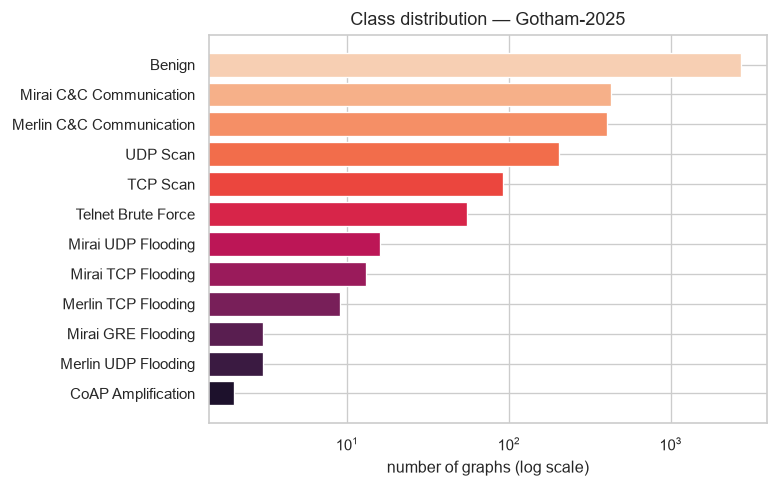

  saved figures\F1b_class_dist_NF-ToN-IoT-v3.png


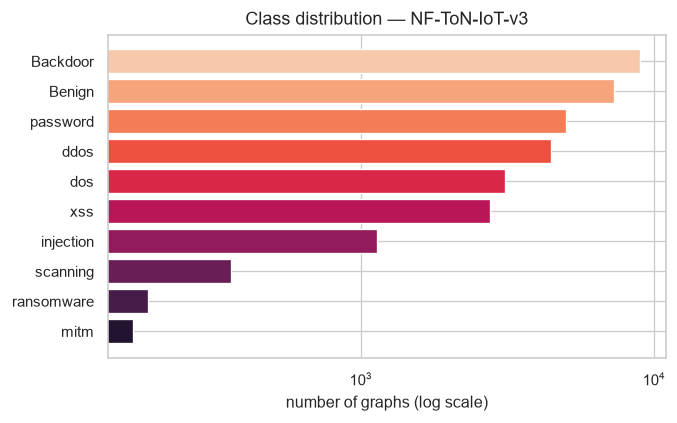

  saved figures\F1c_class_dist_NF-BoT-IoT-v3.png


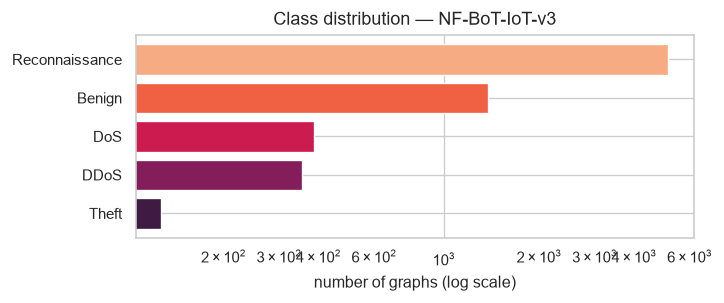

  saved figures\F1d_class_dist_NF-UNSW-NB15-v3.png


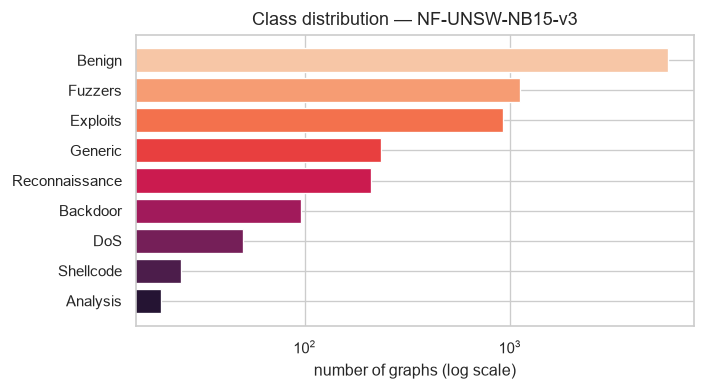

,Dataset,Majority class,Majority count,Minority class,Minority count,Imbalance (maj/min)
0,Gotham-2025,Benign,2733,CoAP Amplification,2,1366.5
1,NF-ToN-IoT-v3,Backdoor,8984,mitm,167,1366.5
2,NF-BoT-IoT-v3,Reconnaissance,5142,Theft,127,1366.5
3,NF-UNSW-NB15-v3,Benign,5916,Analysis,20,1366.5


In [ ]:
letters = ['a', 'b', 'c', 'd', 'e']
imbalance_rows = []

for i, (name, root) in enumerate(DATASETS.items()):
    if not os.path.isdir(root):
        continue
    cnt = Counter(graph_label(g, THRESHOLDS[name]) for g in all_graphs(root))
    if not cnt:
        continue
    ser = pd.Series(cnt).sort_values(ascending=True)

    fig, ax = plt.subplots(figsize=(6, max(2.2, 0.35 * len(ser))))
    ax.barh(ser.index, ser.values,
            color=sns.color_palette('rocket', len(ser)))
    ax.set_xscale('log')
    ax.set_xlabel('number of graphs (log scale)')
    ax.set_title(f'Class distribution — {name}')
    save_fig(fig, f'F1{letters[i]}_class_dist_{slug(name)}')

    imbalance_rows.append({
        'Dataset': name,
        'Majority class': ser.idxmax(), 'Majority count': int(ser.max()),
        'Minority class': ser.idxmin(), 'Minority count': int(ser.min()),
        'Imbalance (maj/min)': round(M.sum(axis=1).max() / max(M.sum(axis=1).min(), 1), 1),
    })

pd.DataFrame(imbalance_rows)

## Section 3 — Graph-level statistics (one PNG per metric, overlaid across datasets)

**Thesis slot:** Figure 2a–2d, Chapter 4.

One figure per metric, with all four datasets overlaid for direct comparison. Justifies `MAX_NODES=128` / `MAX_EDGES=20000`.

Output files:
- `F2a_nodes_per_graph.png`
- `F2b_edges_per_graph.png`
- `F2c_edges_per_node.png`
- `F2d_components_per_graph.png`

  saved figures\F2a_nodes_per_graph.png


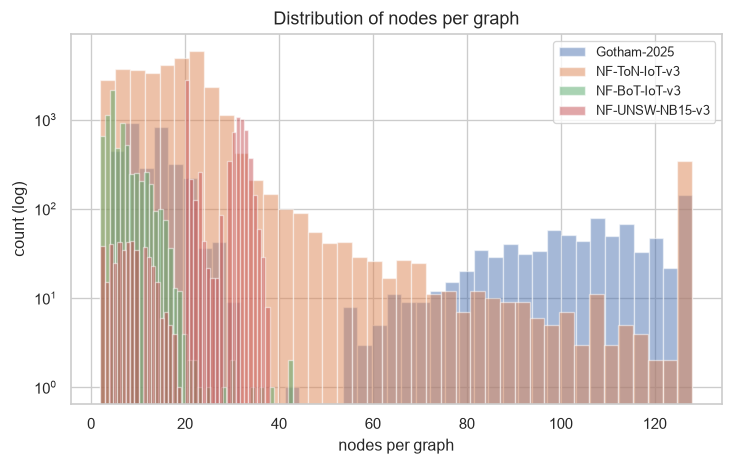

  saved figures\F2b_edges_per_graph.png


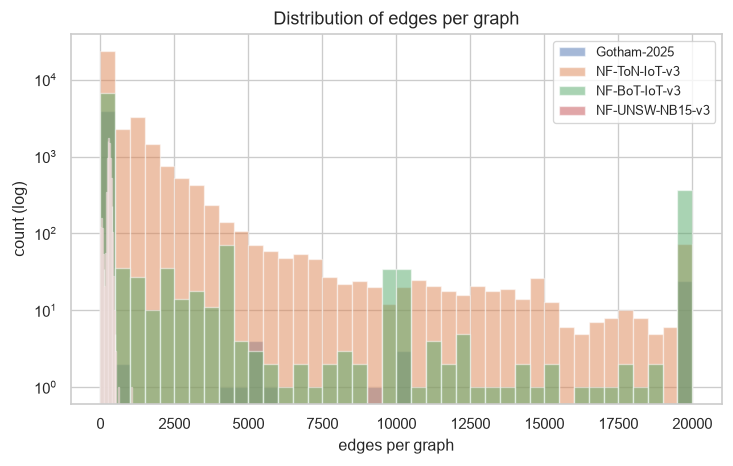

  saved figures\F2c_edges_per_node.png


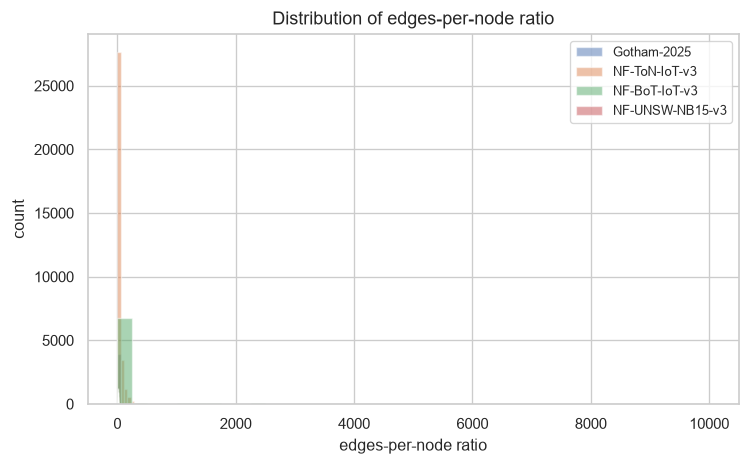

  saved figures\F2d_components_per_graph.png


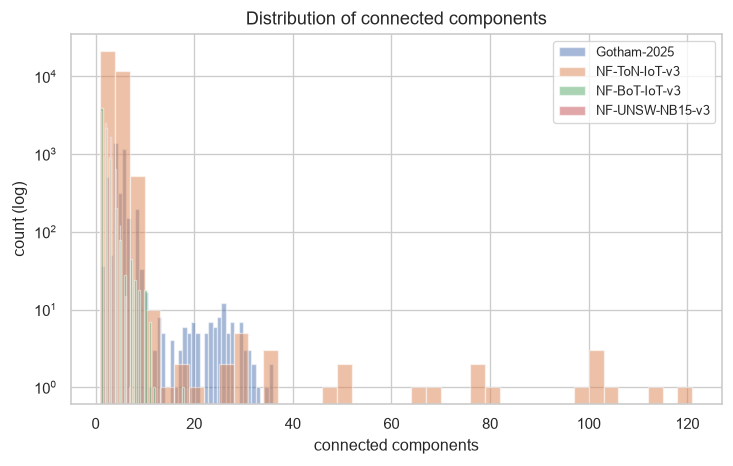

In [28]:
stats = defaultdict(list)
for name, root in DATASETS.items():
    if not os.path.isdir(root):
        continue
    for g in all_graphs(root):
        stats[name].append(graph_stats(g))

metrics = [
    ('F2a_nodes_per_graph',      0, 'nodes per graph',        True),
    ('F2b_edges_per_graph',      1, 'edges per graph',        True),
    ('F2c_edges_per_node',       2, 'edges-per-node ratio',   False),
    ('F2d_components_per_graph', 3, 'connected components',   True),
]

for fname, col, label, logscale in metrics:
    fig, ax = plt.subplots(figsize=(7, 4))
    for name, arr in stats.items():
        arr = np.asarray(arr)
        if arr.size == 0:
            continue
        ax.hist(arr[:, col], bins=40, alpha=0.5, label=name)
    if logscale:
        ax.set_yscale('log')
    ax.set_xlabel(label)
    ax.set_ylabel('count (log)' if logscale else 'count')
    ax.set_title(f'Distribution of {label}')
    ax.legend(fontsize=8)
    save_fig(fig, fname)

## Section 4 — Feature distributions + correlation (one PNG per dataset, split into node / edge / corr)

**Thesis slot:** Appendix.

For each dataset, three separate files, each saved and shown inline:
- `F3<i>_nodefeats_<dataset>.png` — grid of node-feature histograms
- `F3<i>_edgefeats_<dataset>.png` — grid of edge-feature histograms
- `F4<i>_corr_<dataset>.png` — edge-feature correlation heatmap

  saved figures\F3a_nodefeats_Gotham-2025.png


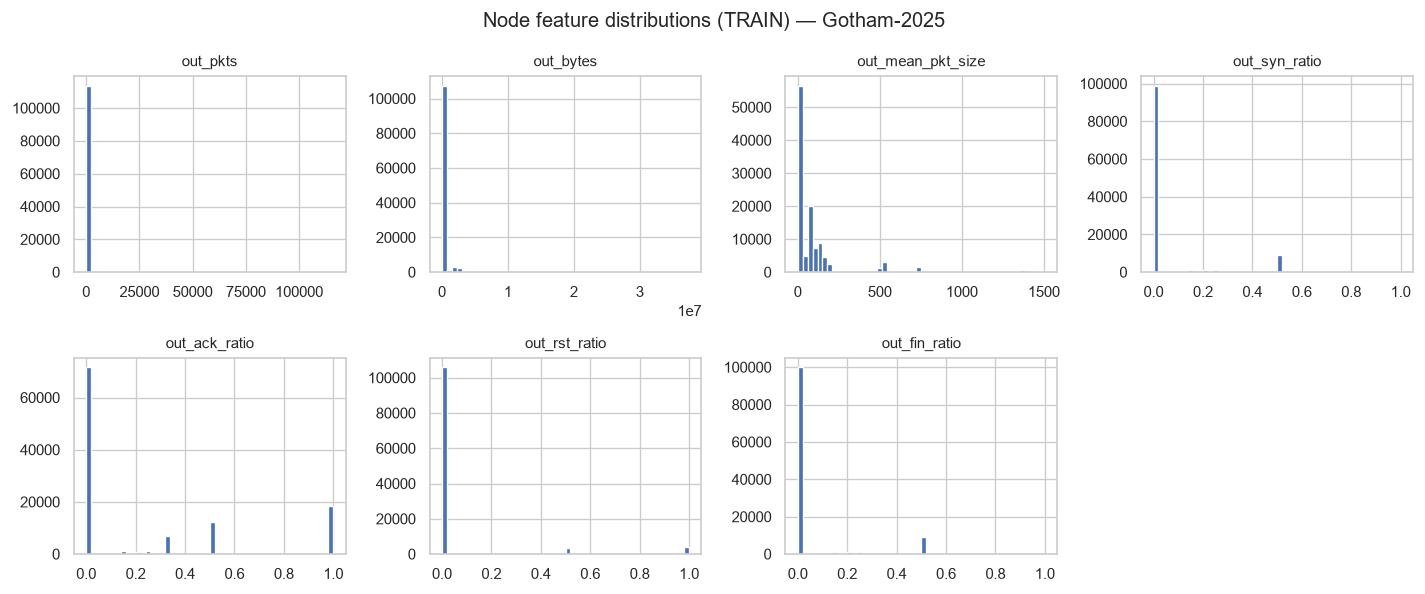

  saved figures\F3a_edgefeats_Gotham-2025.png


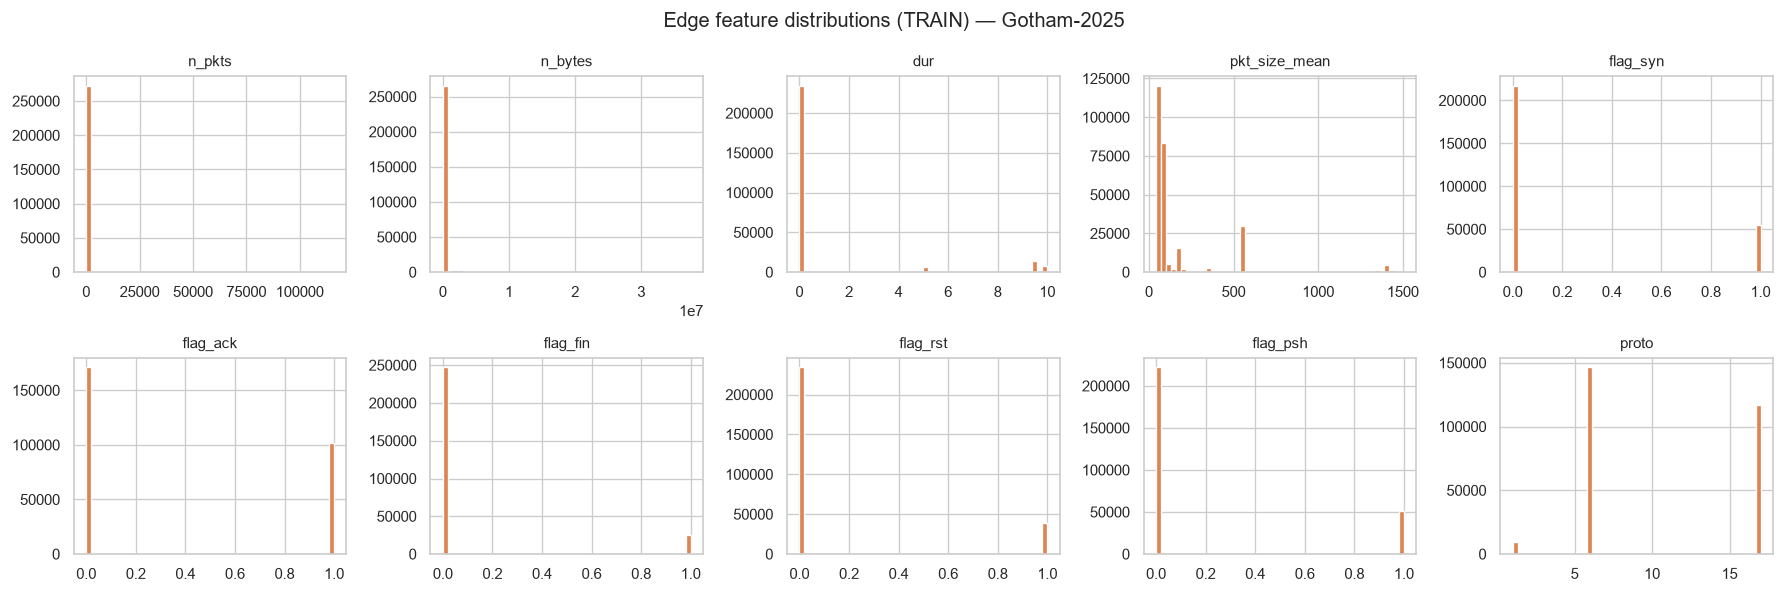

  saved figures\F4a_corr_Gotham-2025.png


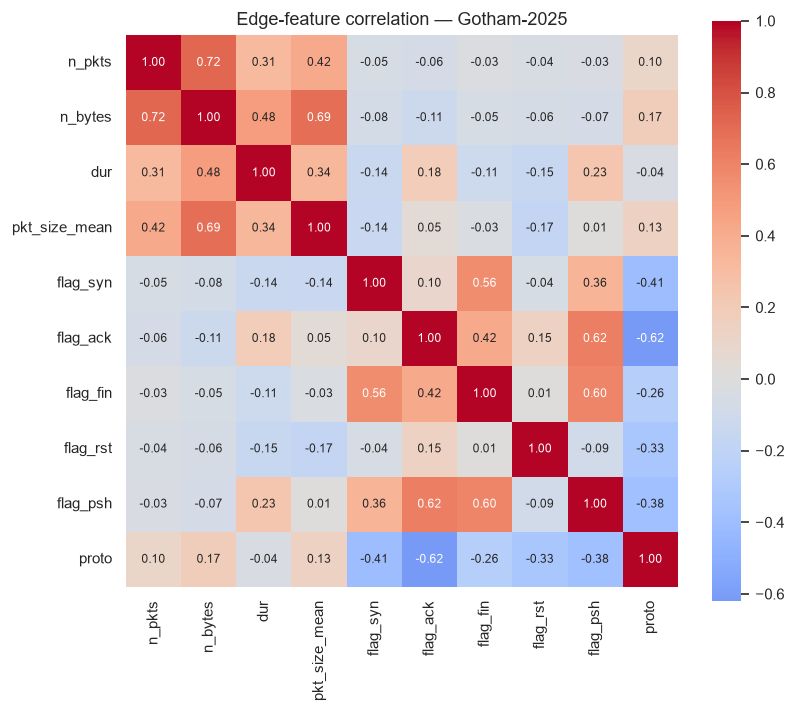

  saved figures\F3b_nodefeats_NF-ToN-IoT-v3.png


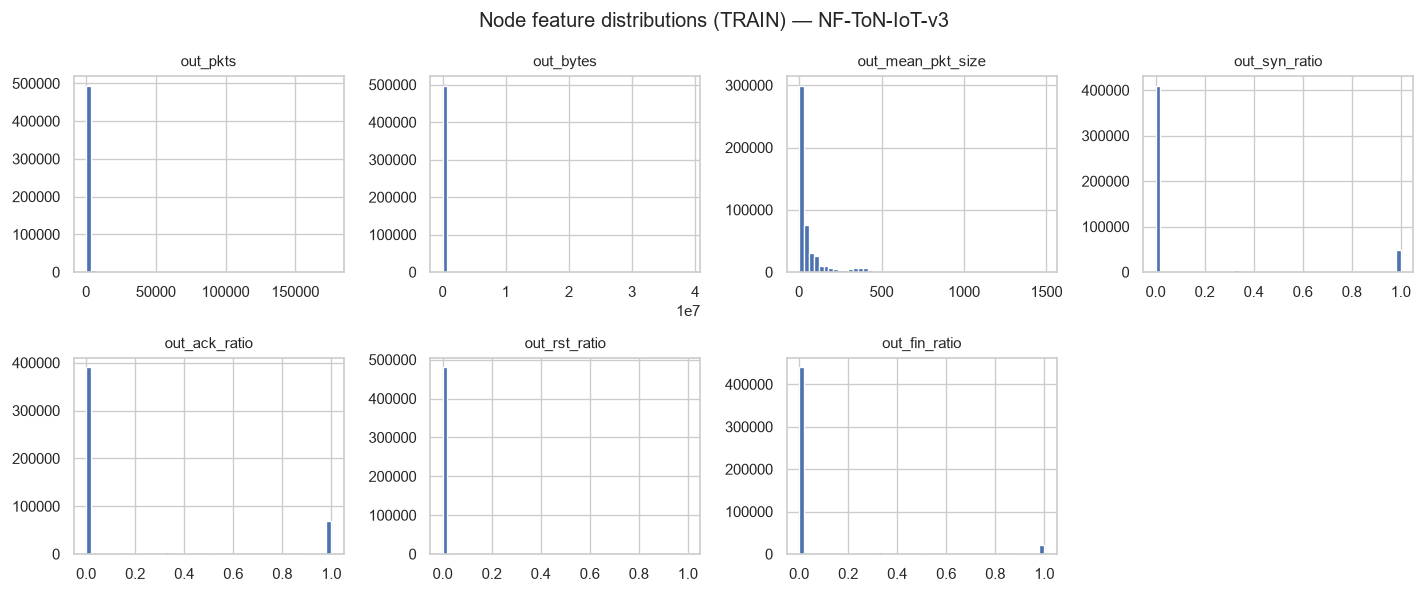

  saved figures\F3b_edgefeats_NF-ToN-IoT-v3.png


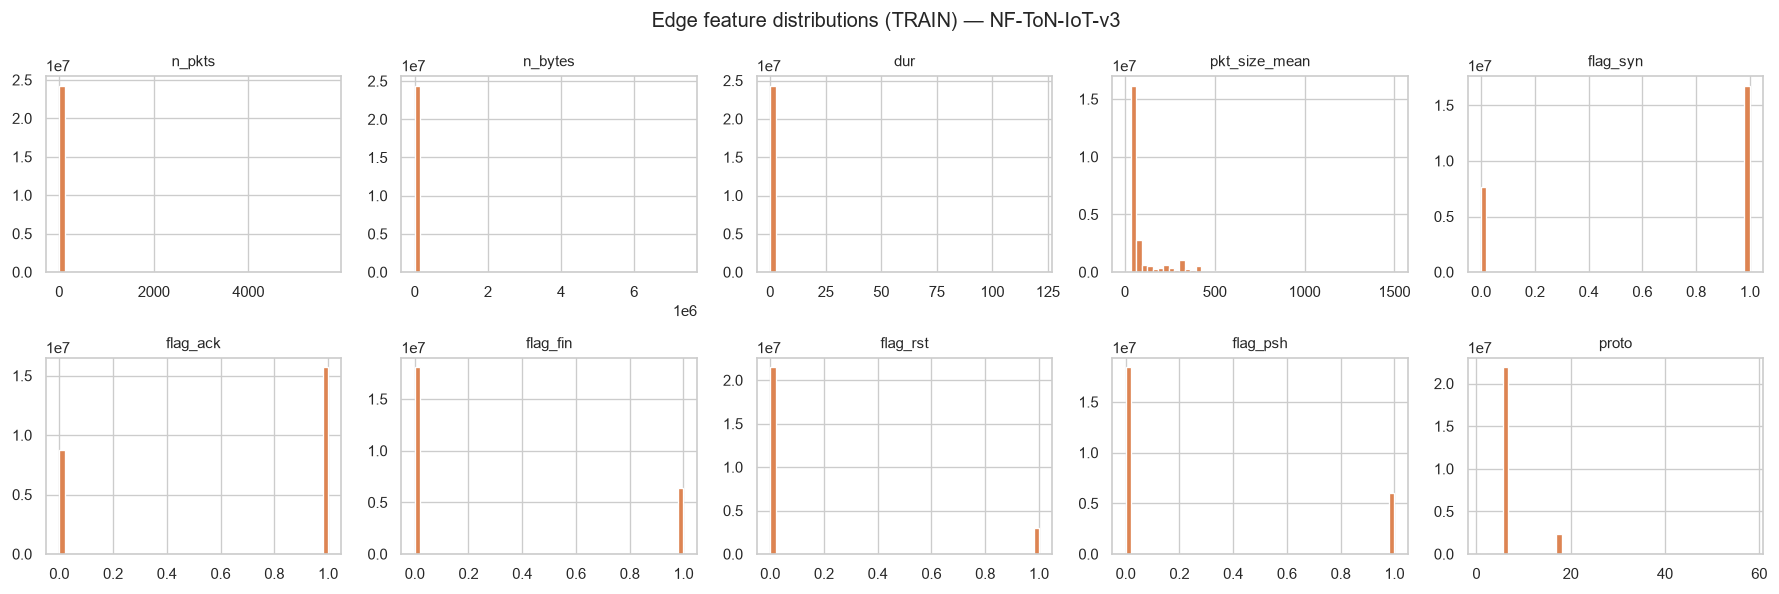

  saved figures\F4b_corr_NF-ToN-IoT-v3.png


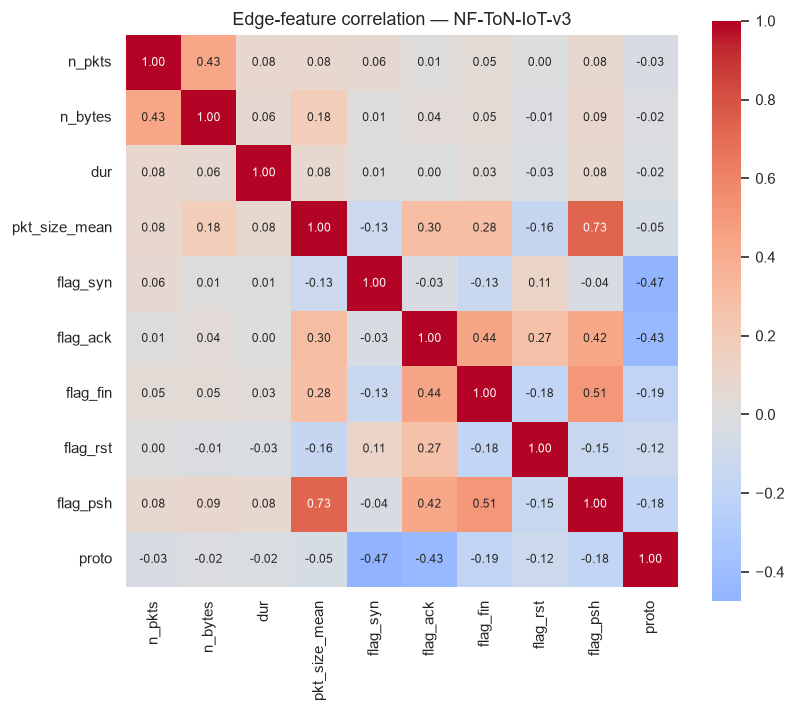

  saved figures\F3c_nodefeats_NF-BoT-IoT-v3.png


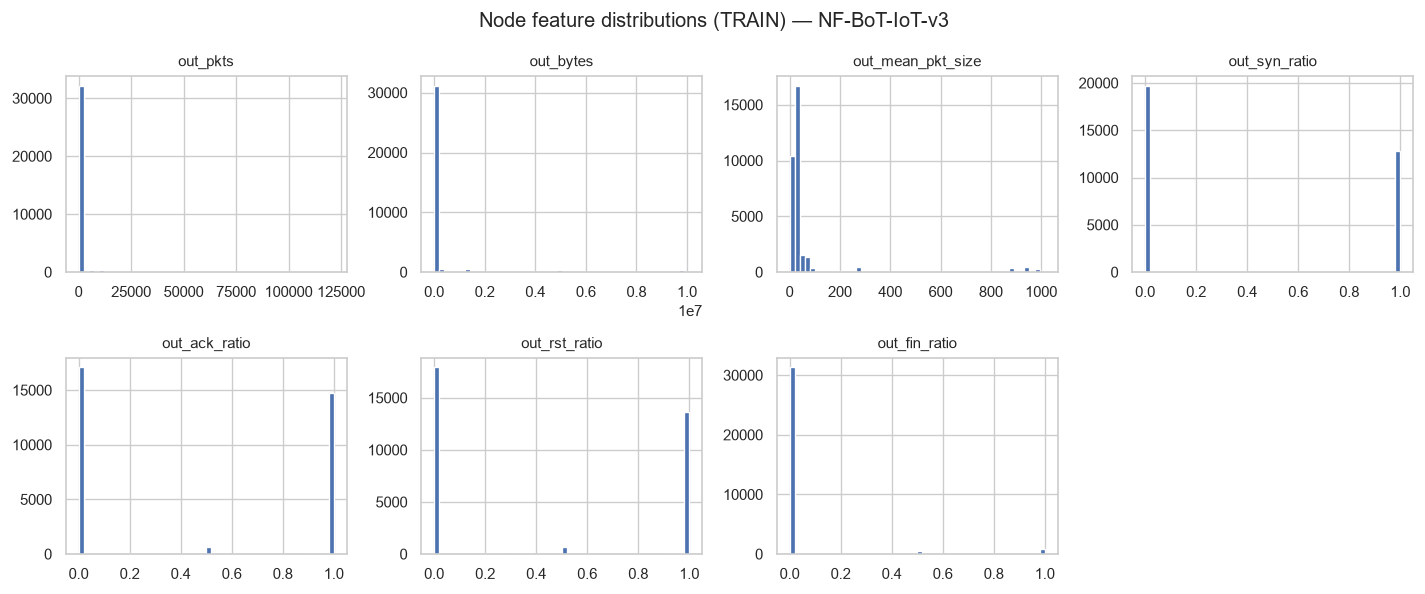

  saved figures\F3c_edgefeats_NF-BoT-IoT-v3.png


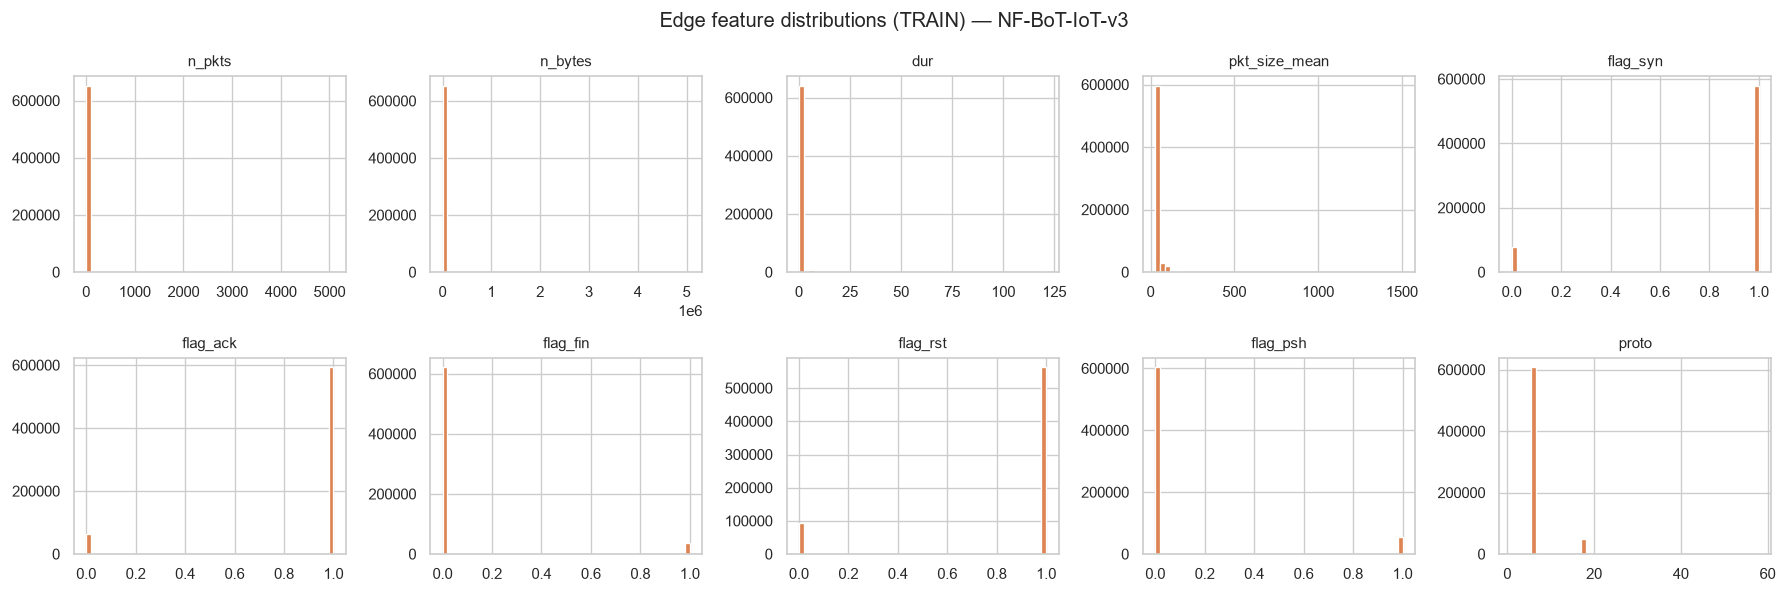

  saved figures\F4c_corr_NF-BoT-IoT-v3.png


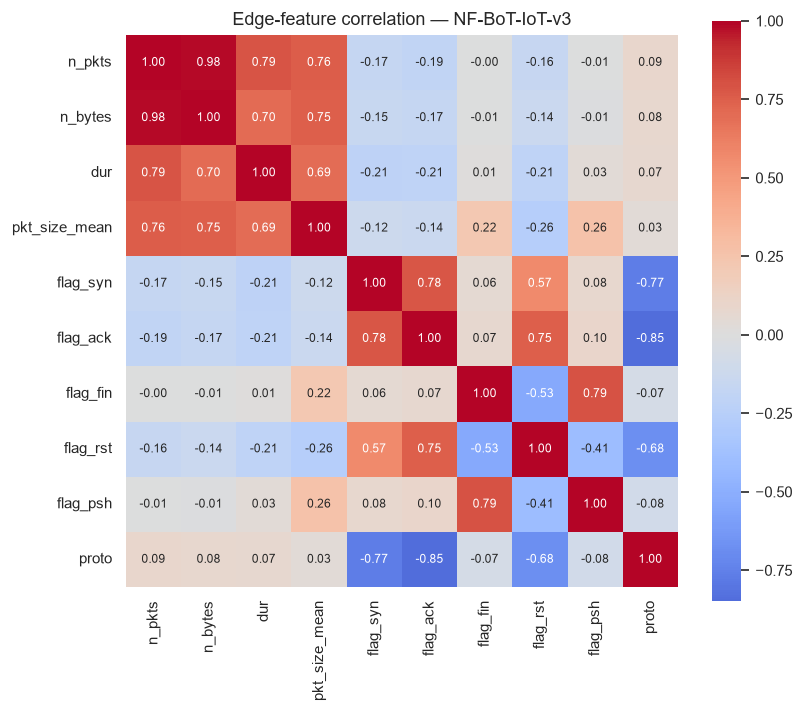

  saved figures\F3d_nodefeats_NF-UNSW-NB15-v3.png


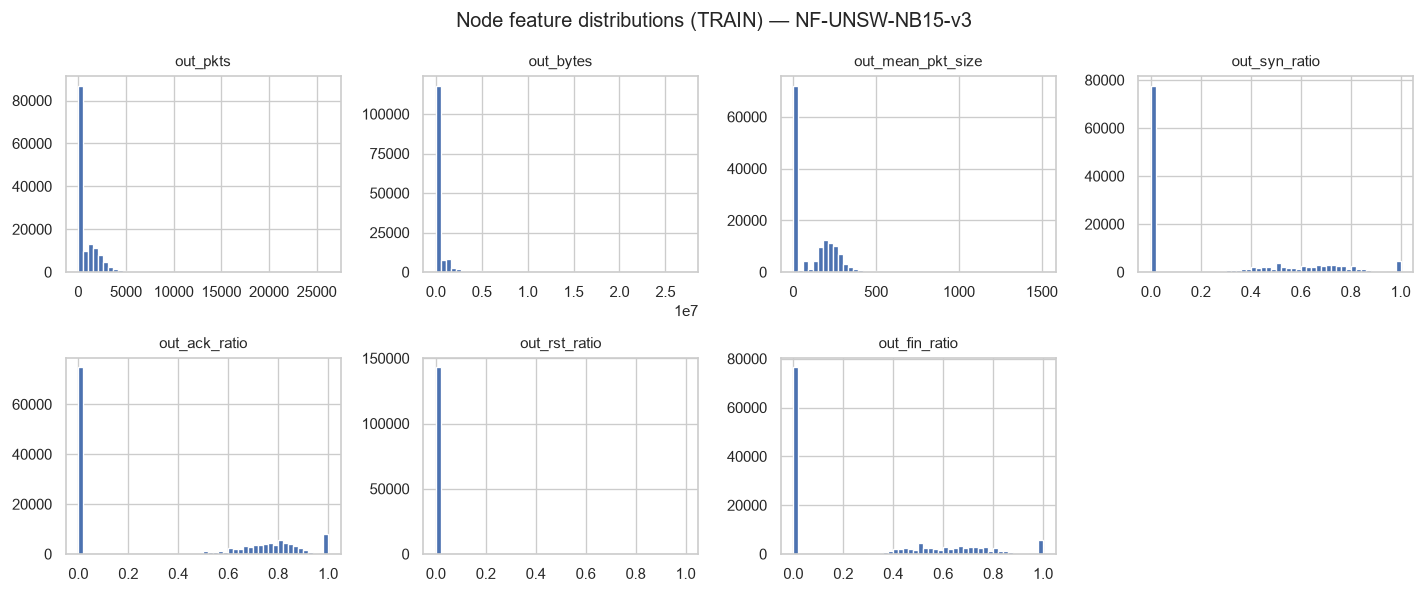

  saved figures\F3d_edgefeats_NF-UNSW-NB15-v3.png


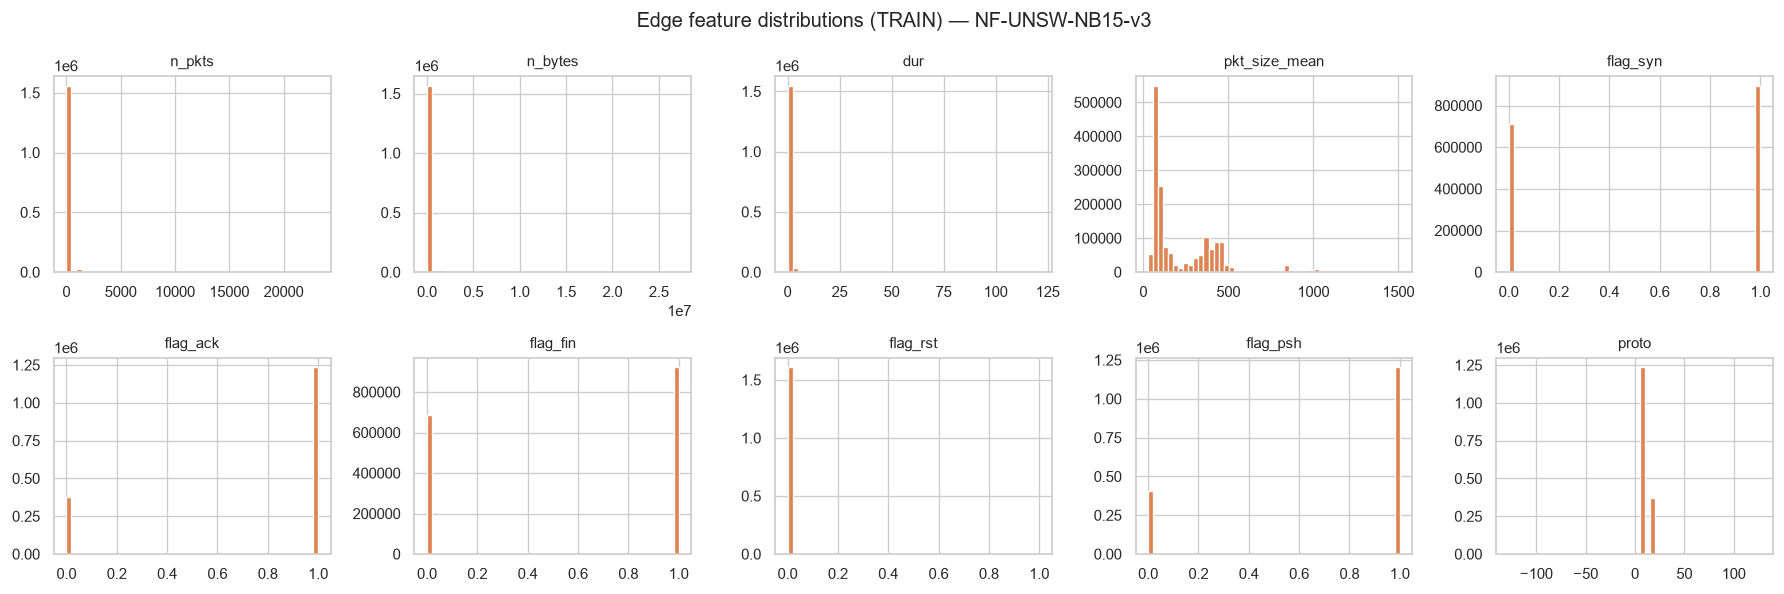

  saved figures\F4d_corr_NF-UNSW-NB15-v3.png


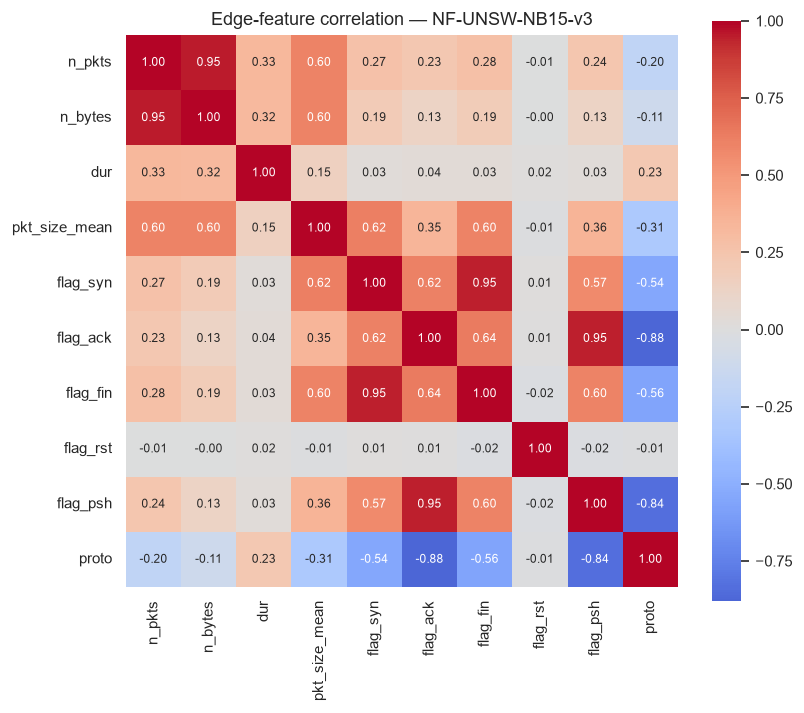

In [29]:
letters = ['a', 'b', 'c', 'd']

for i, (name, root) in enumerate(DATASETS.items()):
    if not os.path.isdir(root):
        continue
    norm = load_norm(root)
    tr = load_split(root, 'train')
    if not tr:
        continue
    X = np.concatenate([g.x.numpy() for g in tr], 0)
    E = np.concatenate([g.edge_attr.numpy() for g in tr], 0)
    sg = slug(name)

    # --- node feature histograms (grid) ---
    ncol = len(norm['node_cols'])
    fig, axes = plt.subplots(2, int(np.ceil(ncol / 2)),
                             figsize=(3 * int(np.ceil(ncol / 2)), 5))
    axes = np.atleast_1d(axes).ravel()
    for j, c in enumerate(norm['node_cols']):
        axes[j].hist(X[:, j], bins=50, color='C0')
        axes[j].set_title(c, fontsize=9)
    for j in range(ncol, len(axes)):
        axes[j].axis('off')
    plt.suptitle(f'Node feature distributions (TRAIN) — {name}')
    plt.tight_layout()
    save_fig(fig, f'F3{letters[i]}_nodefeats_{sg}')

    # --- edge feature histograms (grid) ---
    ecol = len(norm['edge_cols'])
    fig, axes = plt.subplots(2, int(np.ceil(ecol / 2)),
                             figsize=(3 * int(np.ceil(ecol / 2)), 5))
    axes = np.atleast_1d(axes).ravel()
    for j, c in enumerate(norm['edge_cols']):
        axes[j].hist(E[:, j], bins=50, color='C1')
        axes[j].set_title(c, fontsize=9)
    for j in range(ecol, len(axes)):
        axes[j].axis('off')
    plt.suptitle(f'Edge feature distributions (TRAIN) — {name}')
    plt.tight_layout()
    save_fig(fig, f'F3{letters[i]}_edgefeats_{sg}')

    # --- correlation heatmap ---
    fig, ax = plt.subplots(figsize=(7, 6))
    corr = pd.DataFrame(E, columns=norm['edge_cols']).corr()
    sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0,
                ax=ax, annot_kws={'size': 7}, square=True)
    ax.set_title(f'Edge-feature correlation — {name}')
    plt.tight_layout()
    save_fig(fig, f'F4{letters[i]}_corr_{sg}')

## Section 5 — Split diagnostics (one PNG per dataset)

**Thesis slot:** Figure 5a–5d, Chapter 4 — mandatory honesty figure.

Separate heatmap per dataset showing the train/val/test count for every attack family. Cells with 0 = class cannot be learned or evaluated.

Output files:
- `F5a_splitcoverage_Gotham-2025.png`
- `F5b_splitcoverage_NF-ToN-IoT-v3.png`
- `F5c_splitcoverage_NF-BoT-IoT-v3.png`
- `F5d_splitcoverage_NF-UNSW-NB15-v3.png`

  saved figures\F5a_splitcoverage_Gotham-2025.png


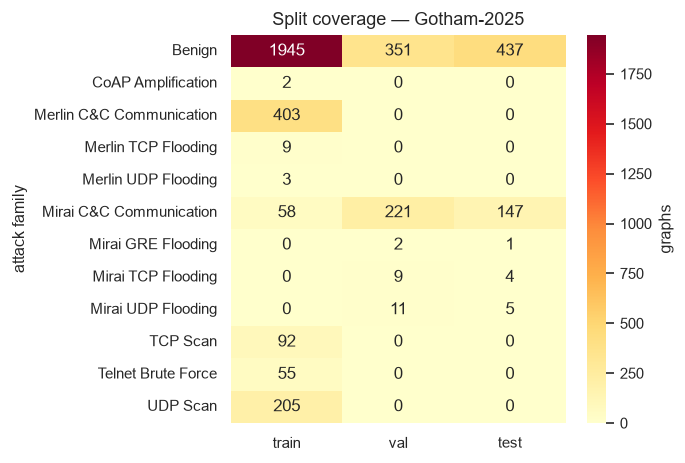

  saved figures\F5b_splitcoverage_NF-ToN-IoT-v3.png


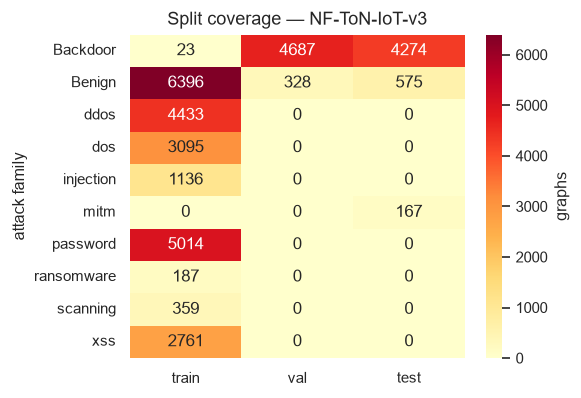

  saved figures\F5c_splitcoverage_NF-BoT-IoT-v3.png


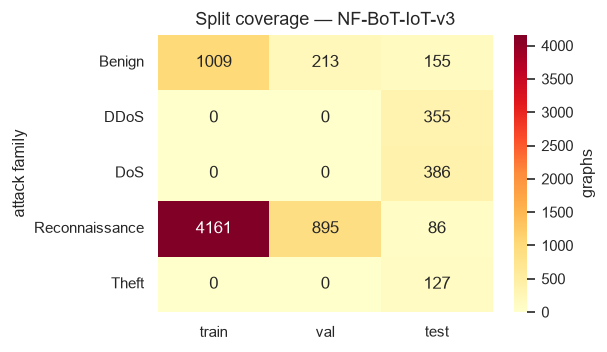

  saved figures\F5d_splitcoverage_NF-UNSW-NB15-v3.png


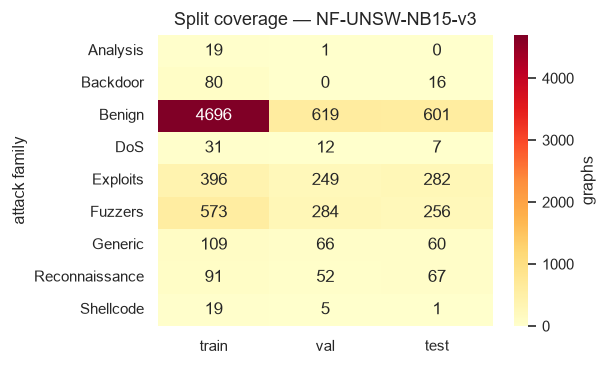

,Dataset,Classes,Zero-train classes,Zero-test classes
0,Gotham-2025,12,Mirai GRE Flooding; Mirai TCP Flooding; Mirai ...,CoAP Amplification; Merlin C&C Communication; ...
1,NF-ToN-IoT-v3,10,mitm,ddos; dos; injection; password; ransomware; sc...
2,NF-BoT-IoT-v3,5,DDoS; DoS; Theft,—
3,NF-UNSW-NB15-v3,9,—,Analysis


In [ ]:
def split_class_matrix(root, thr):
    tr = load_split(root, 'train')
    va = load_split(root, 'val')
    te = load_split(root, 'test')
    if tr is None:
        return None
    def counts(gs):
        return Counter(graph_label(g, thr) for g in (gs or []))
    ctr, cva, cte = counts(tr), counts(va), counts(te)
    classes = sorted(set(ctr) | set(cva) | set(cte))
    return pd.DataFrame({
        'train': [ctr.get(c, 0) for c in classes],
        'val':   [cva.get(c, 0) for c in classes],
        'test':  [cte.get(c, 0) for c in classes],
    }, index=classes)

letters = ['a', 'b', 'c', 'd']
coverage_rows = []

for i, (name, root) in enumerate(DATASETS.items()):
    if not os.path.isdir(root):
        continue
    M = split_class_matrix(root, THRESHOLDS[name])
    if M is None:
        continue

    fig, ax = plt.subplots(figsize=(4.5, max(3.0, 0.35 * len(M))))
    sns.heatmap(M, annot=True, fmt='d', cmap='YlOrRd', ax=ax,
                cbar_kws={'label': 'graphs'})
    ax.set_title(f'Split coverage — {name}')
    ax.set_ylabel('attack family')
    save_fig(fig, f'F5{letters[i]}_splitcoverage_{slug(name)}')

    zero_tr = M.index[M['train'] == 0].tolist()
    zero_te = M.index[M['test'] == 0].tolist()
    coverage_rows.append({
        'Dataset': name,
        'Classes': len(M),
        'Zero-train classes': '; '.join(zero_tr) or '—',
        'Zero-test classes':  '; '.join(zero_te) or '—',
    })

pd.DataFrame(coverage_rows)

## Section 6 — Window gaps and run lengths (one PNG per metric)

**Thesis slot:** Figure 6a–6b, Chapter 3 (Methodology).

Justifies `MAX_WINDOW_GAP_SEC=60` and picks `N` for the Stage-2 temporal module.

Output files:
- `F6a_window_gaps.png`
- `F6b_consecutive_runs.png`

  saved figures\F6a_window_gaps.png


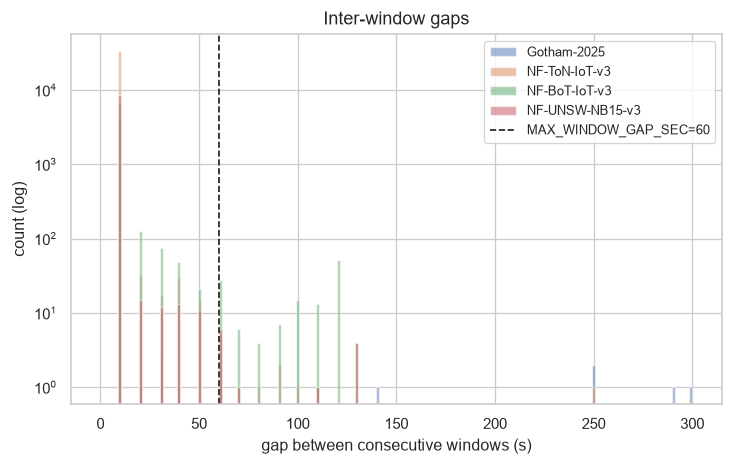

  saved figures\F6b_consecutive_runs.png


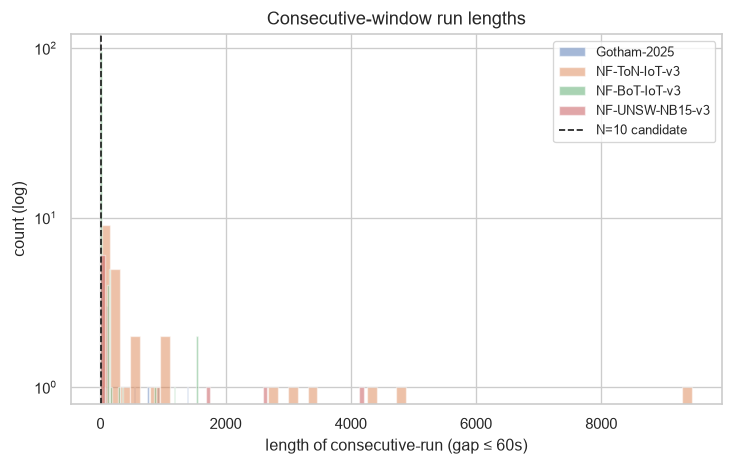

In [31]:
def window_gaps(gs):
    ts = sorted(g.window_start_unix for g in gs)
    if len(ts) < 2:
        return np.array([])
    return np.diff(ts)

# --- Figure 6a: gap histogram ---
fig, ax = plt.subplots(figsize=(7, 4))
for name, root in DATASETS.items():
    if not os.path.isdir(root):
        continue
    gaps = window_gaps(all_graphs(root))
    if gaps.size == 0:
        continue
    ax.hist(gaps, bins=200, range=(0, 300), alpha=0.5,
            label=name, log=True)
ax.axvline(60, ls='--', c='k', lw=1, label='MAX_WINDOW_GAP_SEC=60')
ax.set_xlabel('gap between consecutive windows (s)')
ax.set_ylabel('count (log)')
ax.set_title('Inter-window gaps')
ax.legend(fontsize=8)
save_fig(fig, 'F6a_window_gaps')

# --- Figure 6b: consecutive-run length histogram ---
fig, ax = plt.subplots(figsize=(7, 4))
for name, root in DATASETS.items():
    if not os.path.isdir(root):
        continue
    gaps = window_gaps(all_graphs(root))
    if gaps.size == 0:
        continue
    seq_lens, run = [], 1
    for d in gaps:
        if d <= 60:
            run += 1
        else:
            seq_lens.append(run)
            run = 1
    seq_lens.append(run)
    ax.hist(seq_lens, bins=60, alpha=0.5, label=name, log=True)
ax.axvline(10, ls='--', c='k', lw=1, label='N=10 candidate')
ax.set_xlabel('length of consecutive-run (gap ≤ 60s)')
ax.set_ylabel('count (log)')
ax.set_title('Consecutive-window run lengths')
ax.legend(fontsize=8)
save_fig(fig, 'F6b_consecutive_runs')

## Section 7 — Attack timeline (one PNG per dataset)

**Thesis slot:** Figure 7a–7d, Chapter 3 — the leakage figure.

Green dashed = train|val boundary, red dashed = val|test. If a family only appears to the right of green, it can never be learned; only to the left of red, it can never be tested.

Output files:
- `F7a_timeline_Gotham-2025.png`
- `F7b_timeline_NF-ToN-IoT-v3.png`
- `F7c_timeline_NF-BoT-IoT-v3.png`
- `F7d_timeline_NF-UNSW-NB15-v3.png`

  saved figures\F7a_timeline_Gotham-2025.png


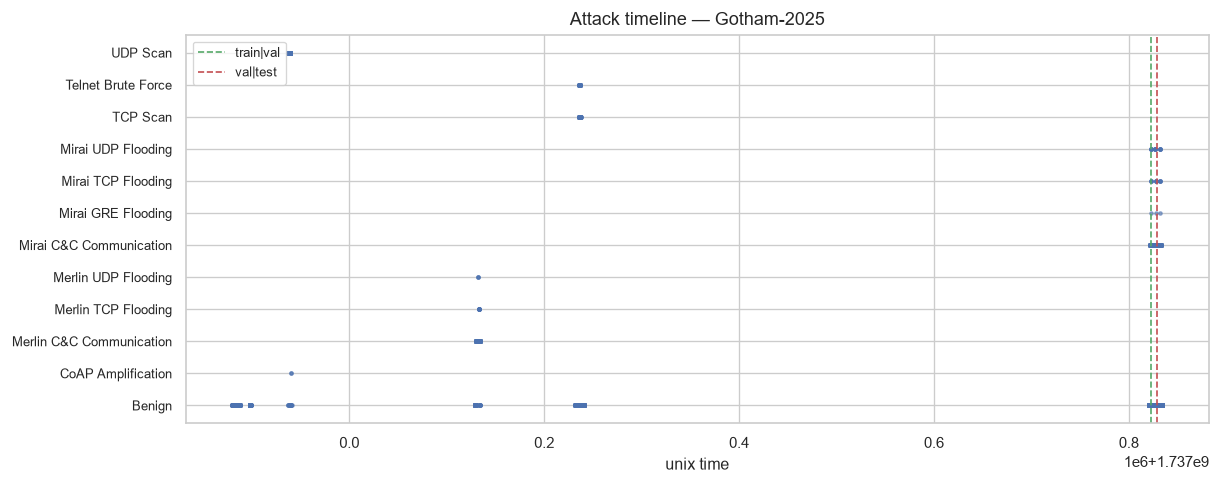

  saved figures\F7b_timeline_NF-ToN-IoT-v3.png


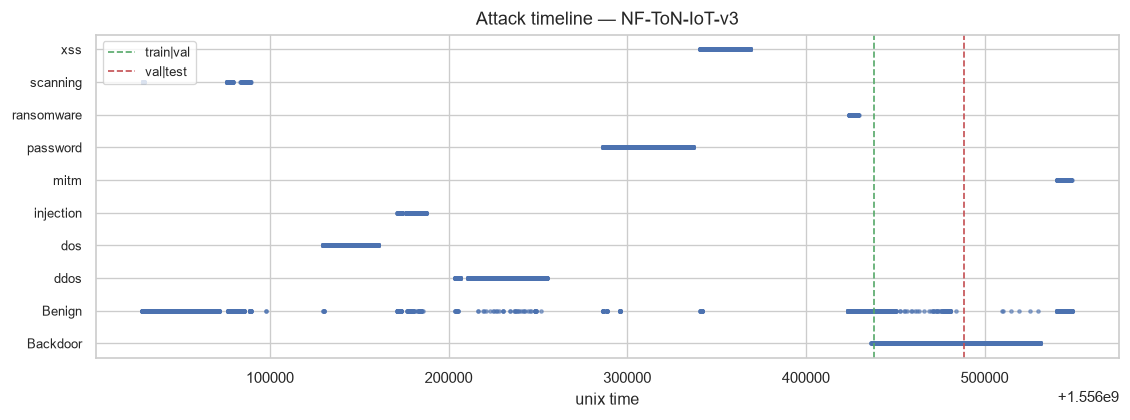

  saved figures\F7c_timeline_NF-BoT-IoT-v3.png


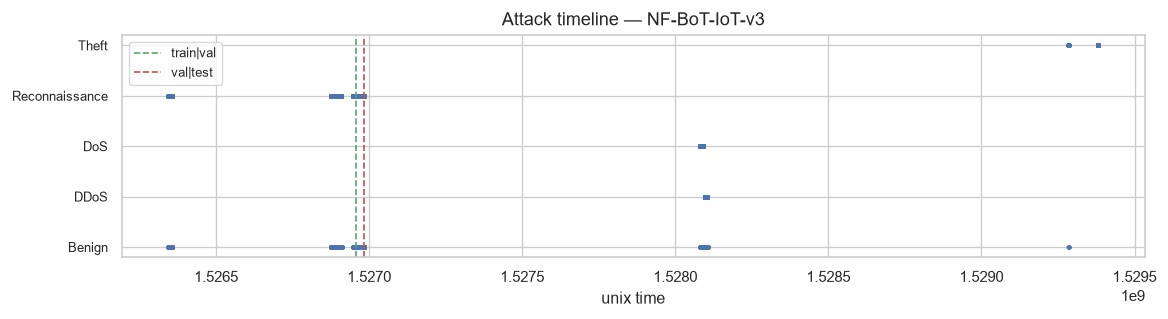

  saved figures\F7d_timeline_NF-UNSW-NB15-v3.png


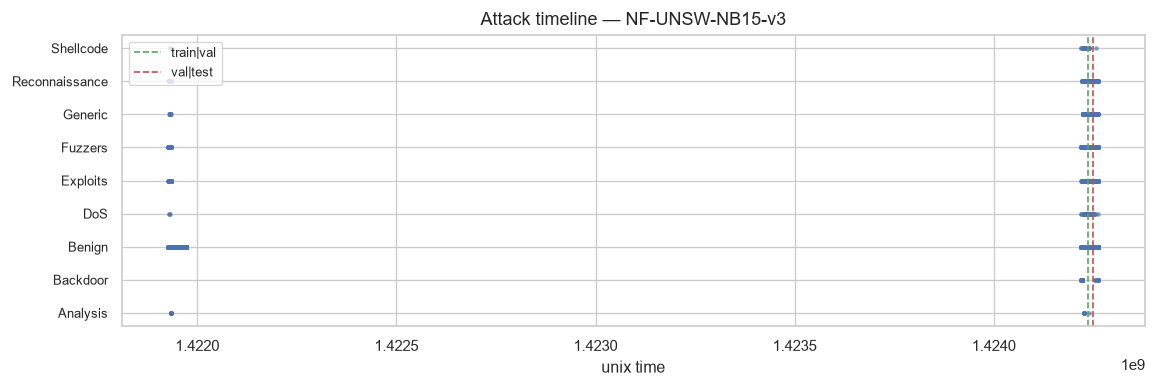

In [32]:
letters = ['a', 'b', 'c', 'd']

for i, (name, root) in enumerate(DATASETS.items()):
    if not os.path.isdir(root):
        continue
    gs = all_graphs(root)
    if not gs:
        continue
    ts = np.array([g.window_start_unix for g in gs])
    ls = [graph_label(g, THRESHOLDS[name]) for g in gs]
    classes = sorted(set(ls))
    y = {c: k for k, c in enumerate(classes)}

    fig, ax = plt.subplots(figsize=(11, max(2.4, 0.35 * len(classes))))
    ax.scatter(ts, [y[l] for l in ls], s=4, alpha=0.55)
    ax.set_yticks(range(len(classes)))
    ax.set_yticklabels(classes, fontsize=8)
    ax.set_xlabel('unix time')
    ax.set_title(f'Attack timeline — {name}')

    n = len(gs)
    order = np.argsort(ts)
    tr_end = ts[order[int(0.70 * n)]]
    va_end = ts[order[int(0.85 * n)]]
    ax.axvline(tr_end, c='g', ls='--', lw=1, label='train|val')
    ax.axvline(va_end, c='r', ls='--', lw=1, label='val|test')
    ax.legend(fontsize=8, loc='upper left')
    save_fig(fig, f'F7{letters[i]}_timeline_{slug(name)}')

## Section 8 — Sample graph topologies (one PNG per dataset)

**Thesis slot:** Figure 8a–8d, Chapter 4.

One PNG per dataset, showing Benign vs. two attack samples side-by-side. Node size ∝ degree.

Output files:
- `F8a_topology_Gotham-2025.png`
- `F8b_topology_NF-ToN-IoT-v3.png`
- `F8c_topology_NF-BoT-IoT-v3.png`
- `F8d_topology_NF-UNSW-NB15-v3.png`

  saved figures\F8a_topology_Gotham-2025.png


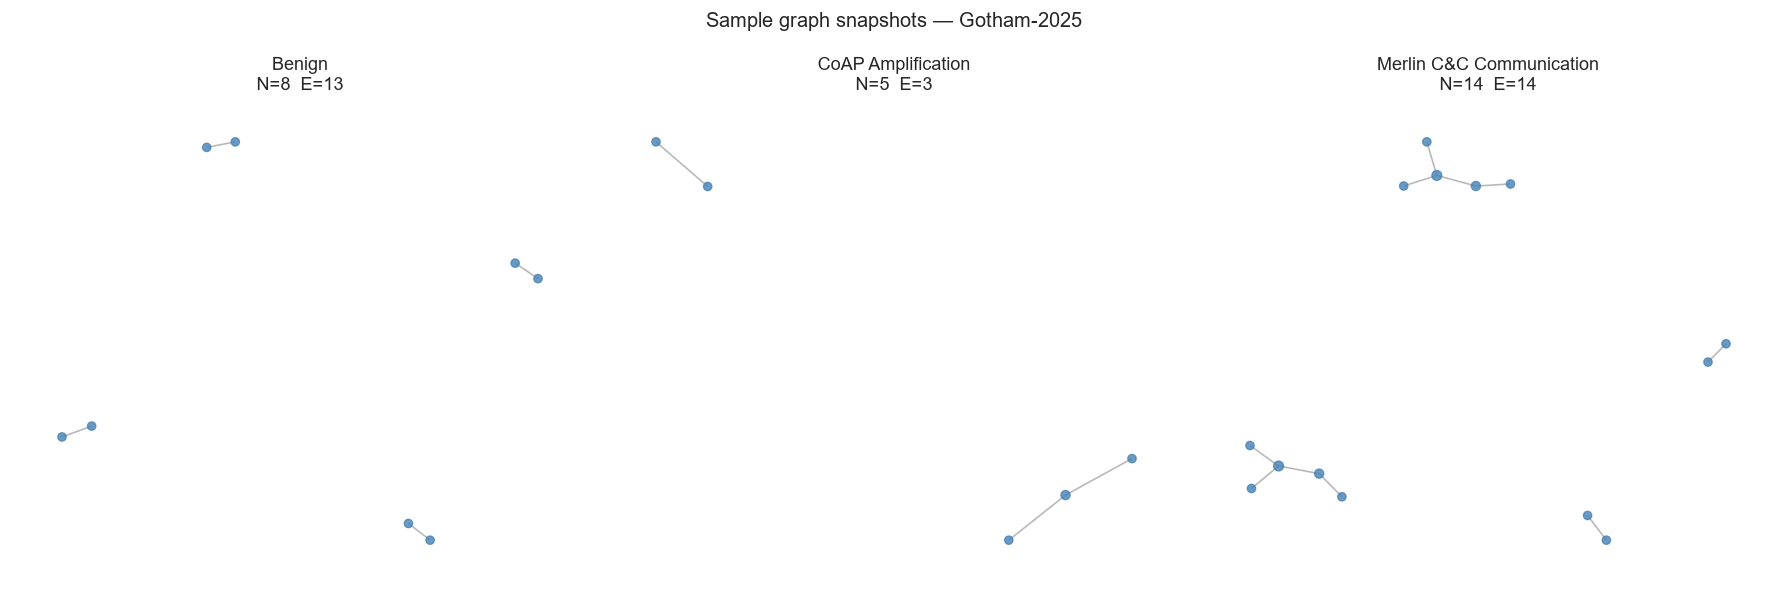

  saved figures\F8b_topology_NF-ToN-IoT-v3.png


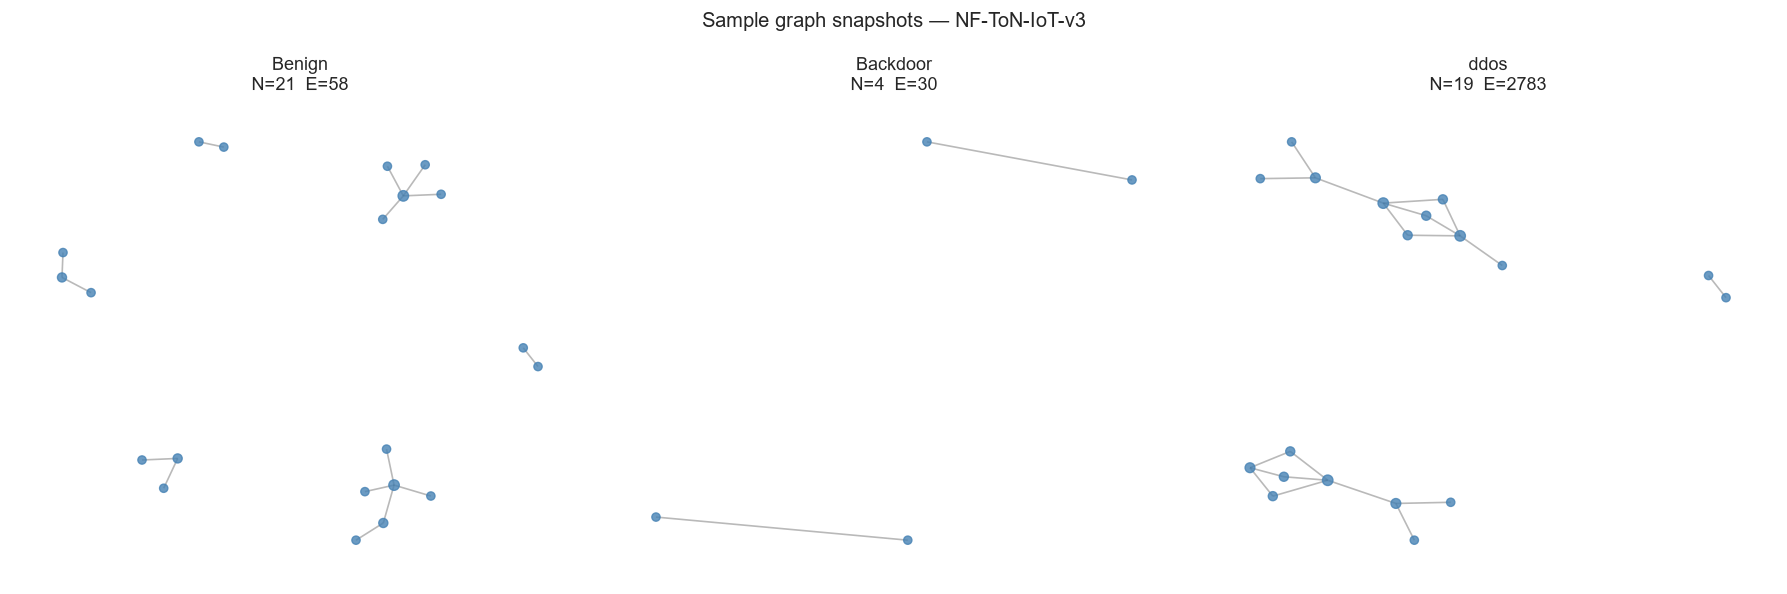

  saved figures\F8c_topology_NF-BoT-IoT-v3.png


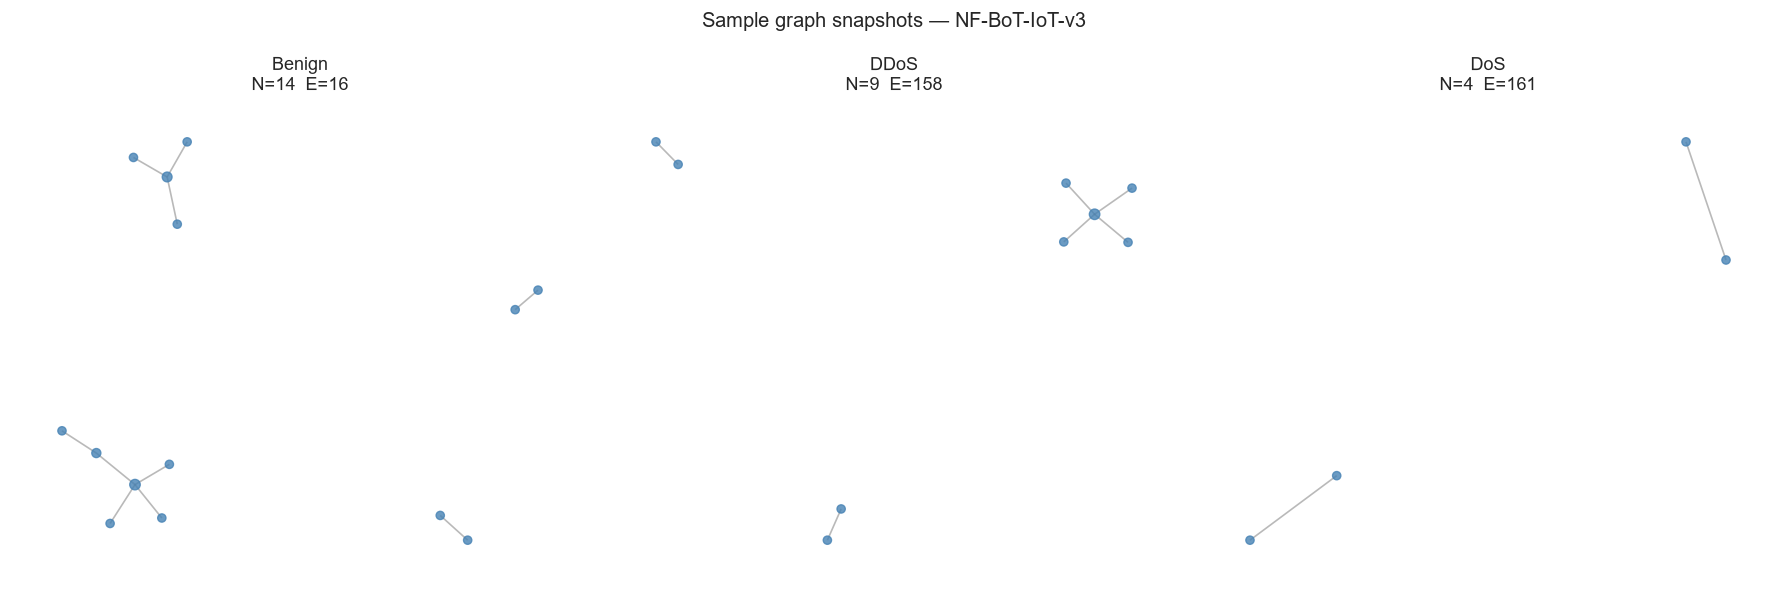

  saved figures\F8d_topology_NF-UNSW-NB15-v3.png


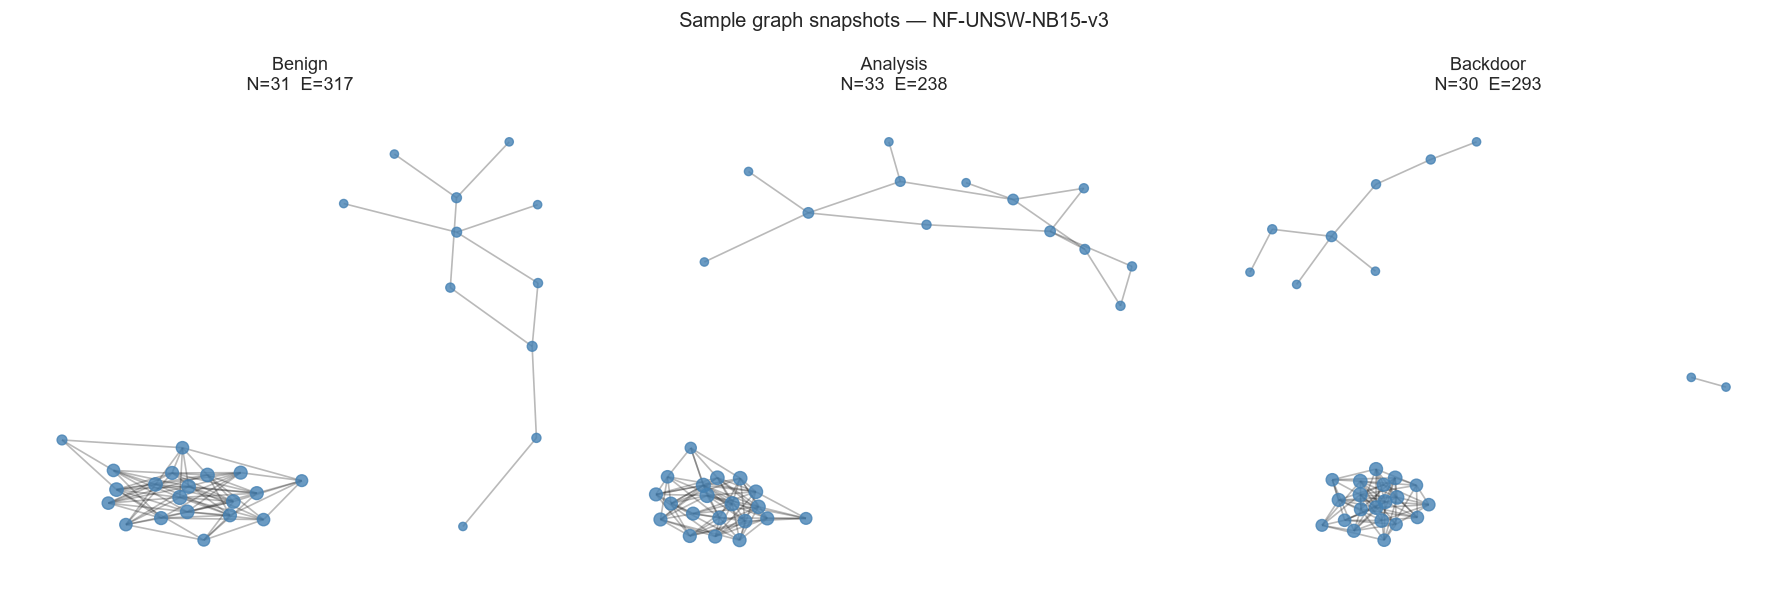

In [ ]:
def pick(gs, cls, thr, seed=0):
    rng = np.random.default_rng(seed)
    idx = [i for i, g in enumerate(gs) if graph_label(g, thr) == cls]
    return gs[int(rng.choice(idx))] if idx else None

letters = ['a', 'b', 'c', 'd']

for i, (name, root) in enumerate(DATASETS.items()):
    if not os.path.isdir(root):
        continue
    gs = all_graphs(root)
    if not gs:
        continue
    thr = THRESHOLDS[name]
    classes = sorted({graph_label(g, thr) for g in gs})
    samples = [pick(gs, 'Benign', thr)]
    samples += [pick(gs, c, thr) for c in classes if c != 'Benign'][:2]

    # --- one combined 1x3 figure per dataset ---
    fig, axes = plt.subplots(1, 3, figsize=(15, 5))
    for ax, g in zip(axes, samples):
        if g is None:
            ax.axis('off')
            continue
        G = to_networkx(g, to_undirected=True)
        pos = nx.spring_layout(G, seed=0, k=0.3)
        sizes = 20 + 5 * np.array([G.degree(n) for n in G.nodes()])
        nx.draw_networkx_nodes(G, pos, ax=ax, node_size=sizes,
                                node_color='steelblue', alpha=.8)
        nx.draw_networkx_edges(G, pos, ax=ax, alpha=.3, arrows=False)
        ax.set_title(f'{graph_label(g, thr)}\nN={g.x.shape[0]}  E={g.edge_index.shape[1]}')
        ax.axis('off')
    plt.suptitle(f'Sample graph snapshots — {name}')
    plt.tight_layout()
    save_fig(fig, f'F8{letters[i]}_topology_{slug(name)}')

In [ ]:
summary = []
for name, root in DATASETS.items():
    if not os.path.isdir(root):
        continue
    M = split_class_matrix(root, THRESHOLDS[name])
    if M is None:
        continue
    gs = all_graphs(root)
    st = np.array([graph_stats(g) for g in gs])
    # per-class totals across splits, used only for the imbalance ratio
    row_sums = M.sum(axis=1)
    summary.append({
        'Dataset': name,
        'Graphs': len(gs),
        'Classes': M.shape[0],
        'Classes w/ 0 train': int((M['train'] == 0).sum()),
        'Classes w/ 0 test':  int((M['test'] == 0).sum()),
        'Imbalance (maj/min)': round(row_sums.max() / max(row_sums.min(), 1), 1),
        'Median nodes': int(np.median(st[:, 0])),
        'Median edges': int(np.median(st[:, 1])),
    })

S = pd.DataFrame(summary)
S

,Dataset,Graphs,Classes,Classes w/ 0 train,Classes w/ 0 test,Imbalance (maj/min),Median nodes,Median edges
0,Gotham-2025,3960,12,3,7,1366.5,14,15
1,NF-ToN-IoT-v3,33435,10,1,7,53.8,17,128
2,NF-BoT-IoT-v3,7387,5,3,0,40.5,5,40
3,NF-UNSW-NB15-v3,8592,9,0,1,295.8,29,281
